## Lab 1: Statistical Inference, Sample Comparisons, A/B Testing ##
**Fiona St. Clair**

**Activity 1: Comparing two proportions**

1. [2pts] Visualize body mass of the penguins across different islands. What does this tell you? 
- ***From the boxplot, we can see that Biscoe penguins are by far the largest with a mean of around 4750 grams. Torgersen and Dream penguins come behind in a close tie with nearly the same average weight of around 3750 grams. Biscoe penguins have the largest range in weights across the different islands, and there is a random outlier Dream penguin that weighs much more than their peers.***
2. [3pts] Using the definitions above, answer the question: Are penguins on Biscoe island larger?  
- ***z-stat = 10.809691047645456 (10.81 points above mean), p-value = 1.5485568601590401e-27 (statistically significant, reject the null)***
    - ***nO = rate of large penguins is the same across all islands***
    - ***n1 = rate of large penguins is NOT the same across all islands***
-  ***Because our p-value is statistically significant, we reject the null hypothesis, and therefore can reason that there is a statistically significant difference in the rate of large penguins acorss all islands.***
3. [2pts] Now visualize which species of penguins live on each island. How does that change your answer to the question: Are penguins on Biscoe island larger?  
- ***After splitting the penguins up by island AND species, it is clear that is it not the island that creates the change, but rather the bread. Gentoo penguins only reside on Biscoe Island and are by far the largest penguins and are therefore skewing their data heavily.***
4. [3pts] Repeat the proportion test considering only one species of penguin. Which species did you choose, and how did that impact your answer? 
- ***I chose Adelie penguins, as they are the only penguins that live on all three islands. After running the test, it returned a z statistic of -0.267 and a p-value of 0.605, and because p-value is larger than .05, we fail to reject the null hypothesis, meaning there is not enough evidence to reason that Adelie penguins on Biscoe have a different rate of size that Adelie penguins on other islands.***

In [ ]:
import os
import pandas as pd
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.weightstats import ttest_ind as sm_ttest
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
os.getcwd()

# question 1

peng = pd.read_csv("C:\\Users\\thefi\\OneDrive\\Desktop\\2 - DS 6021 Predictive Modeling\\DS6021-Predictive_Modeling\\data\\penguins.csv")
peng["is_large"] = peng["body_mass_g"] > peng["body_mass_g"].median() # from lab
peng = peng.dropna(subset=["body_mass_g"]) # drop rows with missing body mass
print(peng.shape)
peng.head()

(342, 9)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,is_large
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007,False
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007,False
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007,False
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007,False
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007,False


In [19]:
print(peng["island"].value_counts(dropna=False))

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64


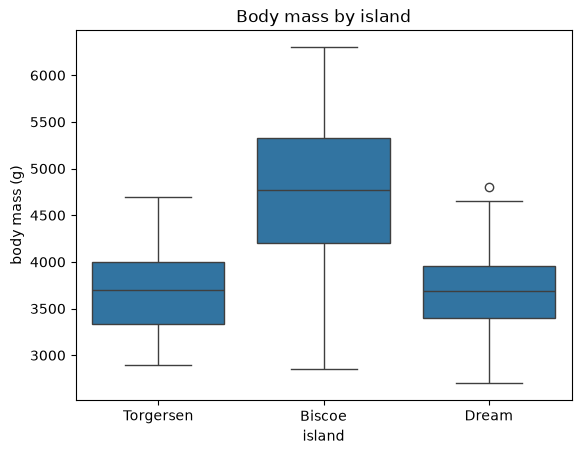

In [37]:
sns.boxplot(
    data=peng.dropna(subset=["island"]),
    x="island",
    y="body_mass_g",
)
plt.ylabel("body mass (g)")
plt.title("Body mass by island")
plt.show()

In [ ]:
# question 2
biscoe_large = peng.loc[peng["island"] == "Biscoe", "is_large"].sum() # sum of large penguins on Biscoe
biscoe_n = (peng["island"] == "Biscoe").sum() # total number of penguins on Biscoe

other_large = peng.loc[peng["island"] != "Biscoe", "is_large"].sum() # sum of large penguins on other islands
other_n = (peng["island"] != "Biscoe").sum() # total number of penguins on other islands

z_stat, p_value = proportions_ztest(
    count=[biscoe_large, other_large],
    nobs=[biscoe_n, other_n],
    alternative="larger"
)

print(z_stat, p_value)

10.809691047645456 1.5485568601590401e-27


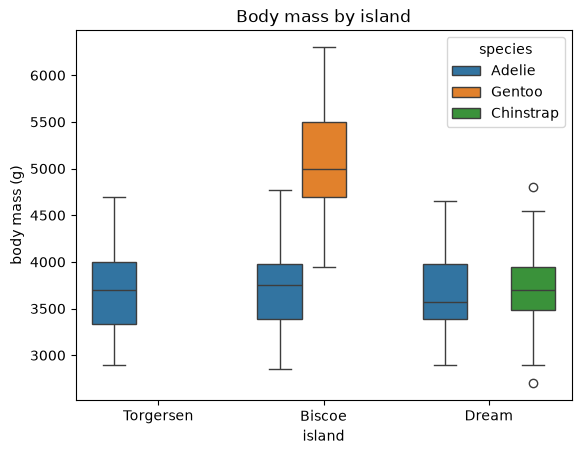

In [ ]:
# question 3

sns.boxplot(
    data=peng.dropna(subset=["island"]),
    x="island",
    y="body_mass_g",
    hue="species",
)
plt.ylabel("body mass (g)")
plt.title("Body mass by island")
plt.show()

In [42]:
pd.crosstab(peng["island"], peng["species"])

species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,44,0,123
Dream,56,68,0
Torgersen,51,0,0


In [44]:
# question 4

adelie = peng.loc[peng["species"] == "Adelie"]

biscoe_large = adelie.loc[adelie["island"] == "Biscoe", "is_large"].sum()
biscoe_n = (adelie["island"] == "Biscoe").sum()

other_large = adelie.loc[adelie["island"] != "Biscoe", "is_large"].sum()
other_n = (adelie["island"] != "Biscoe").sum()

z_stat, p_value = proportions_ztest(
    count=[biscoe_large, other_large],
    nobs=[biscoe_n, other_n],
    alternative="larger"
)

print(z_stat, p_value)

-0.266904085463221 0.6052284945104162


**Activity 2: Digging Further into ANOVA with class data**

1. [2 points] Re-bin the data into three groups instead of 5: [<1 year | 1-3 years | 4+ years] and plot hours of sleep for these three groups.  
2. [2 points] Repeat the test for equal variance with these three groups, as well as the ANOVA. What conclusions can you draw? Are any other assumptions violated?  
3. [4 points] Reflection: One thing we have been ignoring in this analysis is the fact that these are ordered variables: e.g. they aren’t independent buckets like in our penguins dataset where the different species have no inherent ordering. Here, <1 year means something in relation to 1-3 years and so forth. Please answer the following questions: 

    - a. How are the original buckets reflective of a poor survey design?  
    - b. Does splitting our data into three buckets vs five improve the survey design?  
    - c. If we were redesigning this survey, what would you recommend in order to answer the question about whether or not students who graduated more recently get more or less  sleep than students who graduated longer ago?   

4. [2 points] Reflection: We’ve been using the in-class survey data to help understand concepts around statistical inference, sample comparisons, and data cleaning. Is this a good dataset to help understand these concepts? Please explain why or why not, and reflect on what this might tell you more broadly about data collection, survey design, and drawing conclusions from a particular set of data.